# **Classificação: Resolvendo problemas multiclasse**

## **Aula 1 - Conhecendo os dados**

### **Carregando os dados**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/classificacao_multiclasse/main/Dados/dados_estudantes.csv')

In [3]:
df.head()

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,...,disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,...,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,...,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduado


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   object 
 1   Migração                                  4424 non-null   object 
 2   Sexo                                      4424 non-null   object 
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   object 
 5   Necessidades educacionais especiais       4424 non-null   object 
 6   Devedor                                   4424 non-null   object 
 7   Taxas de matrícula em dia                 4424 non-null   object 
 8   Bolsista                                  4424 non-null   object 
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                    

### **Entendendo os dados**

In [5]:
df['Target'].unique()

array(['Desistente', 'Graduado', 'Matriculado'], dtype=object)

In [6]:
df.describe()

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações)
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,23.265145,11.566139,1.228029,0.001969,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,7.587816,2.663850,1.382711,2.269935,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,17.000000,7.600000,-0.800000,-4.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,9.400000,0.300000,-1.700000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,20.000000,11.100000,1.400000,0.320000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,25.000000,13.900000,2.600000,1.790000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,70.000000,16.200000,3.700000,3.510000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


## **Aula 2 - Explorando os dados**

### **Dados demográficos**

* Estado civil
* Migração
* Sexo
* Idade na inscrição
* Estrangeiro

In [7]:
df['Estado civil'].value_counts(normalize = True)*100

Estado civil
Solteiro               88.584991
Casado                  8.566908
Divorciado              2.056962
União Estável           0.565099
Legalmente Separado     0.135624
Viúvo                   0.090416
Name: proportion, dtype: float64

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

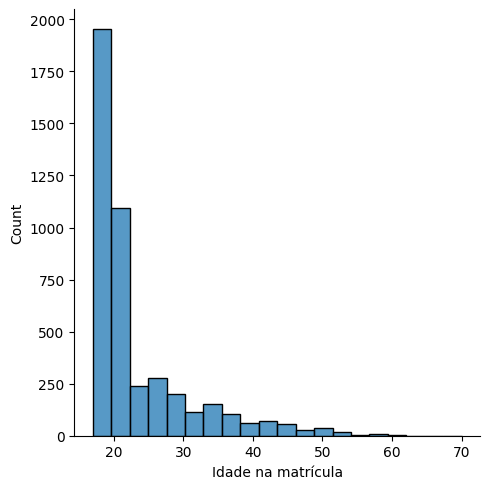

In [9]:
sns.displot(df['Idade na matrícula'], bins=20)
plt.show()

In [10]:
color_dict = {'Desistente': '#e34c42','Graduado': '#4dc471', 'Matriculado': '#3b71db'}

# Definindo a paleta de cores
sns.set_palette(list(color_dict.values()))

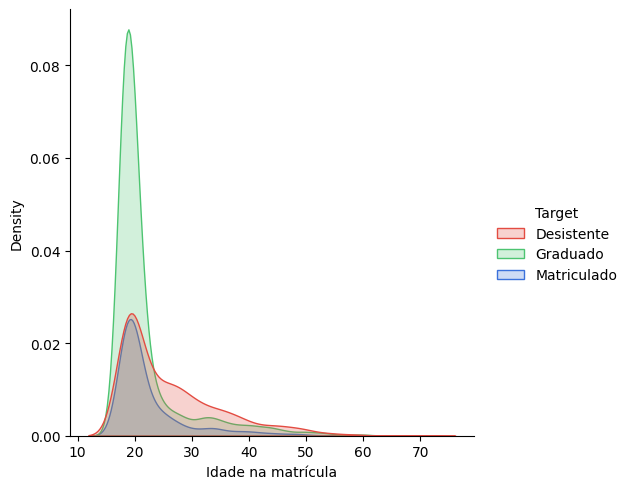

In [11]:
sns.displot(data=df,x='Idade na matrícula', hue='Target', kind = 'kde', fill=True)

In [12]:
df['Estrangeiro'].value_counts(normalize=True)*100

Estrangeiro
Não    97.513562
Sim     2.486438
Name: proportion, dtype: float64

In [13]:
df['Sexo'].value_counts(normalize=True)*100

Sexo
Feminino     64.82821
Masculino    35.17179
Name: proportion, dtype: float64

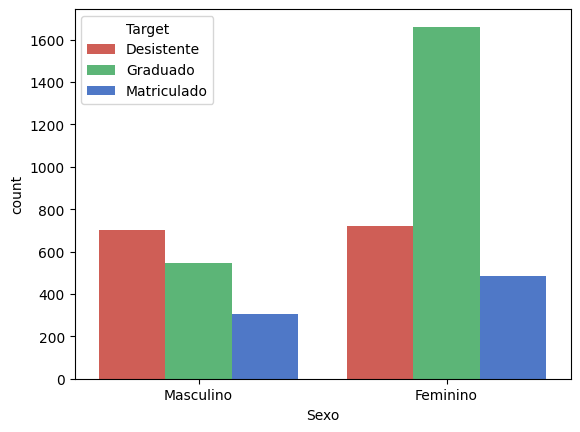

In [14]:
sns.countplot(x='Sexo', hue='Target', data=df)
plt.show()

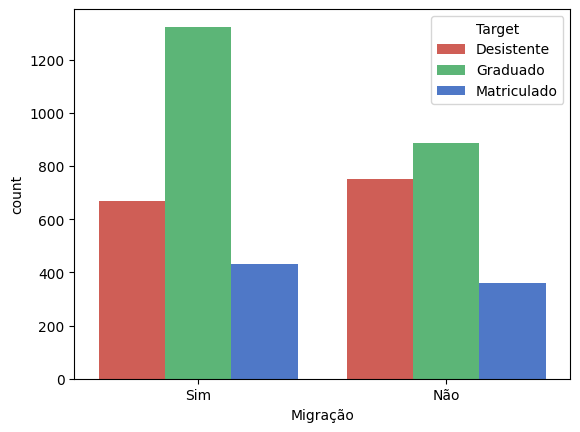

In [15]:
sns.countplot(x='Migração', hue='Target', data=df)
plt.show()

### **Dados socioeconômicos e macroeconômicos**

**Socioeconômicos**
* Necessidades educacionais especiais
* Devedor
* Taxas de matrícula em dia
* Bolsista

**Macroeconômicos**
* Taxa de desemprego
* Taxa de inflação
* PIB

#### **Socioeconômicos**

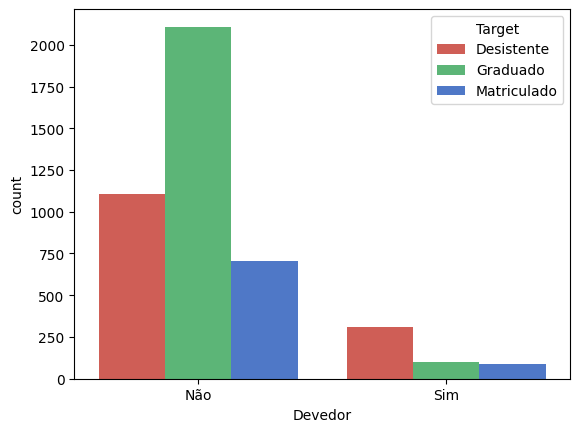

In [16]:
sns.countplot(x='Devedor',hue='Target',data=df)
plt.show()

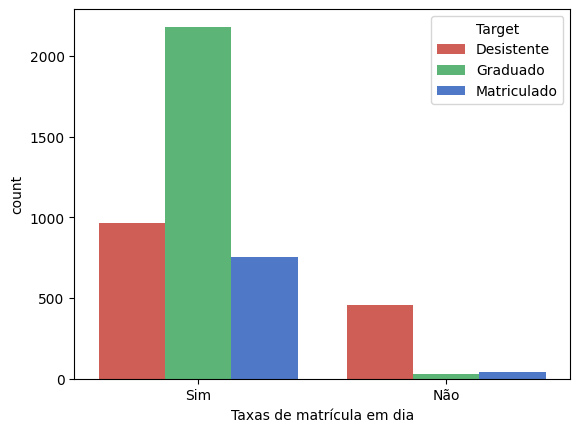

In [17]:
sns.countplot(x='Taxas de matrícula em dia',hue='Target',data=df)
plt.show()

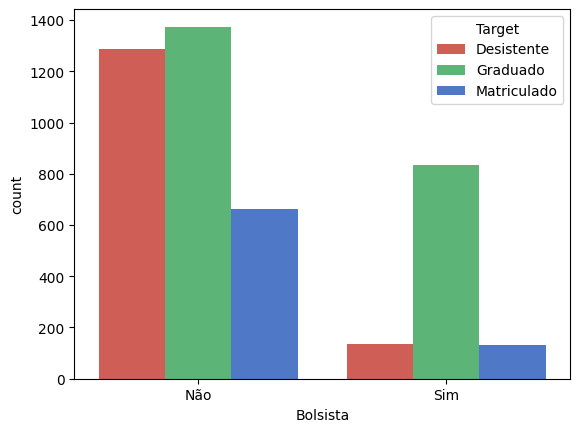

In [18]:
sns.countplot(x='Bolsista',hue='Target',data=df)
plt.show()

In [19]:
df['Necessidades educacionais especiais'].value_counts(normalize=True)*100

Necessidades educacionais especiais
Não    98.847197
Sim     1.152803
Name: proportion, dtype: float64

In [20]:
df.groupby('Target')['Necessidades educacionais especiais'].value_counts(normalize=True)*100

Target       Necessidades educacionais especiais
Desistente   Não                                    98.803659
             Sim                                     1.196341
Graduado     Não                                    98.958805
             Sim                                     1.041195
Matriculado  Não                                    98.614610
             Sim                                     1.385390
Name: proportion, dtype: float64

#### **Macroeconômicos**

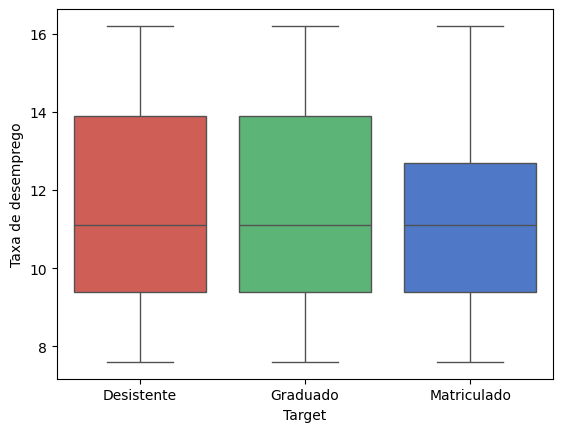

In [21]:
sns.boxplot(x='Target', y='Taxa de desemprego', data=df, hue='Target')
plt.show()

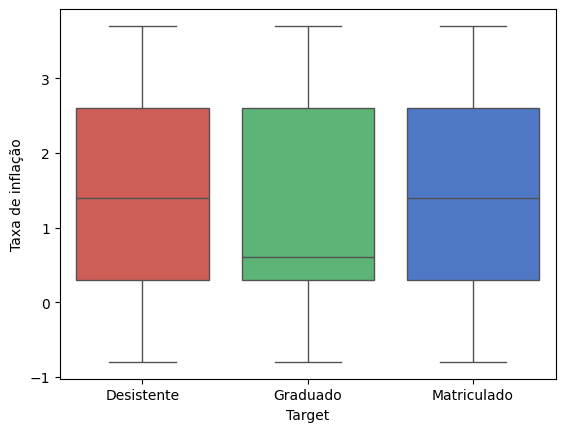

In [22]:
sns.boxplot(x='Target', y='Taxa de inflação', data=df, hue='Target')
plt.show()

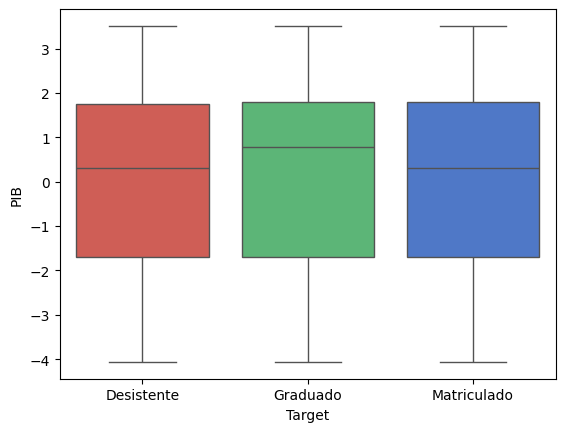

In [23]:
sns.boxplot(x='Target', y='PIB', data=df, hue='Target')
plt.show()

### **Dados no momento da matrícula**

* Curso
* Período
* Qualificação prévia

In [24]:
import plotly.express as px

In [25]:
# Calcula as contagens das combinações Curso-Target
contagem = df.groupby(['Curso','Target']).size().reset_index(name='Contagem')

# Calcula as porcentagens
contagem['Porcentagem'] = contagem.groupby('Curso')['Contagem'].transform(lambda x: (x/x.sum()) * 100)
# Cria o gráfico interativo
fig = px.bar(contagem, y='Curso', x='Porcentagem', color='Target', orientation='h',
             color_discrete_map=color_dict)
# Mostra o gráfico
fig.show()

In [26]:
df['Qualificação prévia'].value_counts(normalize=True)*100

Qualificação prévia
Educação secundária                                         84.018987
Curso de especialização tecnológica                          4.950271
Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente     3.661844
Educação superior - licenciatura                             2.848101
Outro - 11º ano de escolaridade                              1.017179
Educação superior - licenciatura (1º ciclo)                  0.904159
Curso técnico superior profissional                          0.813743
Educação superior - bacharelado                              0.519892
Frequência de educação superior                              0.361664
12º ano de escolaridade - não concluído                      0.248644
Educação superior - mestrado                                 0.180832
Educação básica 2º ciclo (6º/7º/8º ano) ou equivalente       0.158228
Educação superior - mestrado (2º ciclo)                      0.135624
11º ano de escolaridade - não concluído                      0.090416


### **Dados acadêmicos**

* disciplinas creditadas
* disciplinas matriculadas
* disciplinas avaliações
* disciplinas aprovadas
* disciplinas notas
* disciplinas sem avaliações
* disciplinas faltas

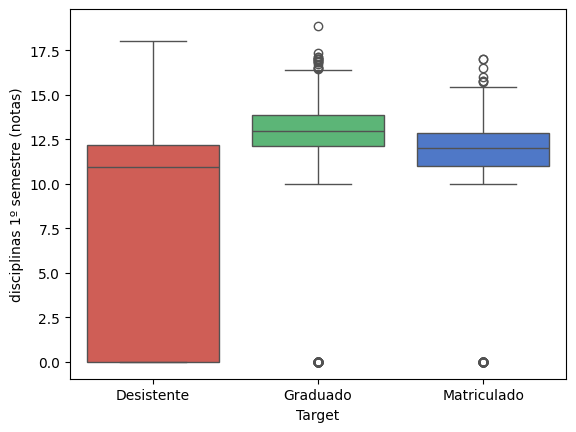

In [27]:
sns.boxplot(x='Target', y='disciplinas 1º semestre (notas)',data=df, hue='Target')
plt.show()

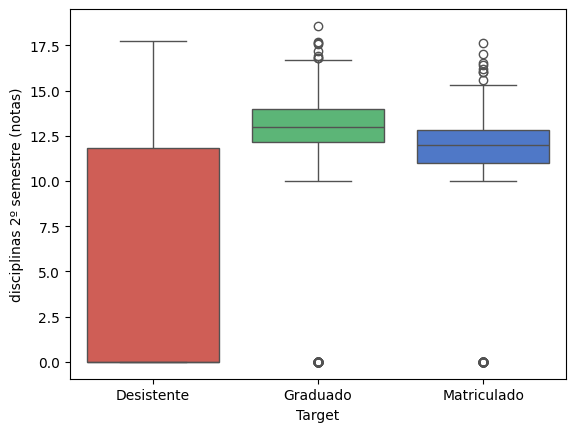

In [28]:
sns.boxplot(x='Target', y='disciplinas 2º semestre (notas)',data=df, hue='Target')
plt.show()

In [29]:
df['Target'].value_counts(normalize=True) * 100

Target
Graduado       49.932188
Desistente     32.120253
Matriculado    17.947559
Name: proportion, dtype: float64

## **Aula 3 - Realizando o treinamento**

### **Preparando os dados**

In [30]:
from sklearn.preprocessing import OneHotEncoder


# Selecionando apenas as colunas categóricas do dataframe
colunas_categoricas = df.select_dtypes(include=['object']).columns[:11]
df_categorico = df[colunas_categoricas]
# Inicializando o OneHotEncoder
enconder = OneHotEncoder(drop='if_binary')
# Ajustando e transformando os dados, criando um novo dataframe com as colunas codificadas
df_encoded = pd.DataFrame(enconder.fit_transform(df_categorico).toarray(), 
                          columns=enconder.get_feature_names_out(colunas_categoricas))
# Combinando as colunas codificadas com as colunas não codificadas do dataframe original
df_final = pd.concat([df.drop(columns=colunas_categoricas), df_encoded], axis = 1)


### **Separando os dados**

In [32]:
X = df_final.drop(columns='Target')
y = df_final['Target']

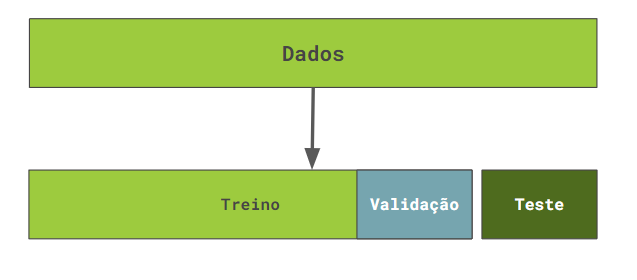

In [37]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, random_state=0)

### **Treinando o modelo com Random Forest Classifier**

In [40]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [51]:
model_rf = RandomForestClassifier(random_state=0, max_depth=10)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_val)

print(f'Acurácia de treino: {model_rf.score(X_train, y_train)}')
print(f'Acurácia de validação: {model_rf.score(X_val, y_val)}')

Acurácia de treino: 0.9002920317062996
Acurácia de validação: 0.7872340425531915


In [52]:
model_gb = GradientBoostingClassifier(random_state=0)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_val)

print(f'Acurácia de treino: {model_gb.score(X_train, y_train)}')
print(f'Acurácia de validação: {model_gb.score(X_val, y_val)}')

Acurácia de treino: 0.8452231956612433
Acurácia de validação: 0.7834793491864831


## **Aula 4 - Avaliando o modelo**

### **Analisando a matriz de confusão**

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [53]:
matriz_confusao = confusion_matrix(y_true=y_val, y_pred=y_pred)

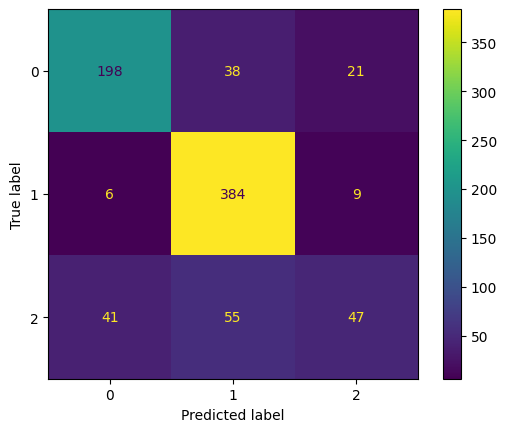

In [54]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot();

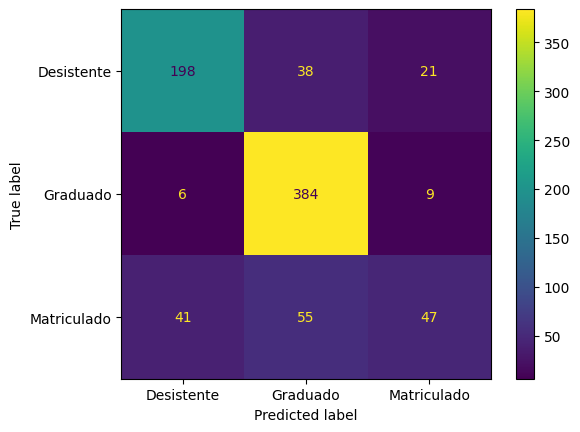

In [56]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=model_rf.classes_)
visualizacao.plot();

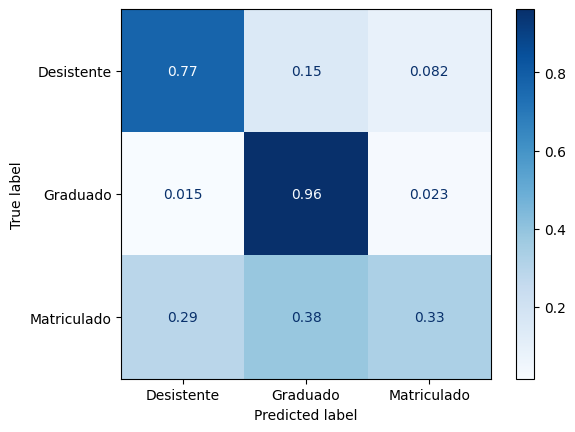

In [58]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues');

### **Analisando o relatório de métricas**

In [59]:
from sklearn.metrics import classification_report

In [62]:
report = classification_report(y_val, y_pred)
print('Relatório de Classificação: \n', report)

Relatório de Classificação: 
               precision    recall  f1-score   support

  Desistente       0.81      0.77      0.79       257
    Graduado       0.81      0.96      0.88       399
 Matriculado       0.61      0.33      0.43       143

    accuracy                           0.79       799
   macro avg       0.74      0.69      0.70       799
weighted avg       0.77      0.79      0.77       799



### **Aplicando a técnica de superamostragem**

In [63]:
y_train.value_counts()

Target
Graduado       1196
Desistente      770
Matriculado     431
Name: count, dtype: int64

In [64]:
from imblearn.over_sampling import SMOTE

In [66]:
oversample = SMOTE(random_state=0)
X_balanced, y_balanced = oversample.fit_resample(X_train, y_train)

In [67]:
y_balanced.value_counts()

Target
Graduado       1196
Desistente     1196
Matriculado    1196
Name: count, dtype: int64

In [70]:
model_rf_balanced = RandomForestClassifier(random_state=0, max_depth=10)
model_rf_balanced.fit(X_balanced, y_balanced)
y_pred = model_rf_balanced.predict(X_val)

### **Analisando as métricas após o balanceamento**

              precision    recall  f1-score   support

  Desistente       0.82      0.72      0.77       257
    Graduado       0.84      0.87      0.86       399
 Matriculado       0.48      0.54      0.50       143

    accuracy                           0.76       799
   macro avg       0.71      0.71      0.71       799
weighted avg       0.77      0.76      0.76       799



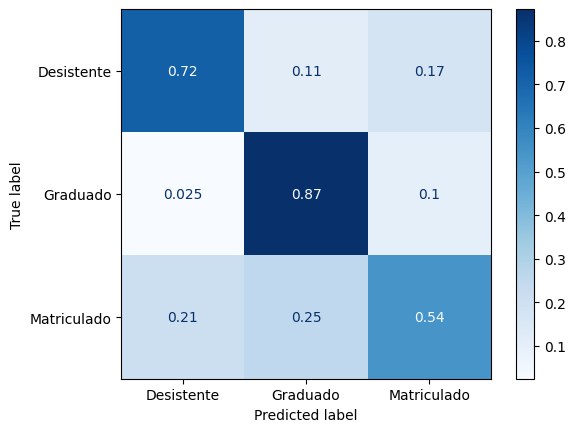

In [71]:
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues');

## **Aula 5 - Validando o modelo**

### **Pipeline para validação**

In [74]:
from imblearn.pipeline import Pipeline as imbpipeline

In [ ]:
model = RandomForestClassifier(max_depth=10)
pipeline = imbpipeline([('oversample', SMOTE()),('Forest', model)])

In [76]:
from sklearn.model_selection import cross_validate, StratifiedKFold

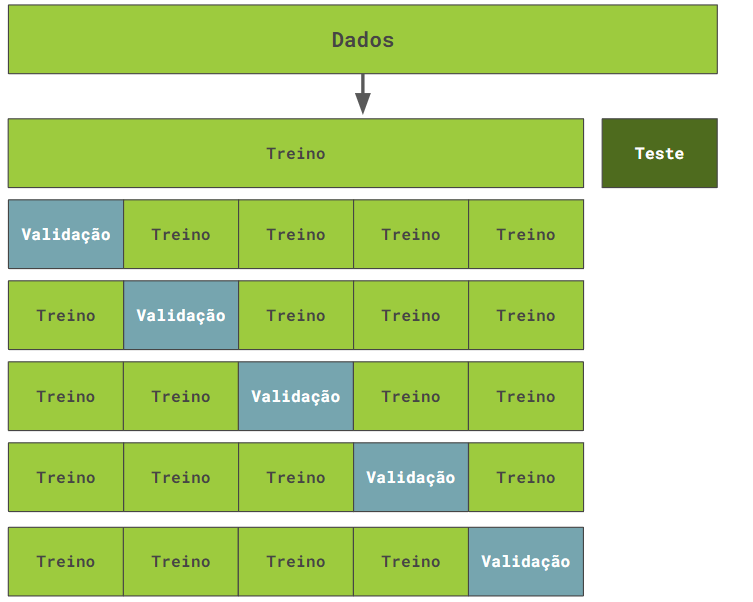

In [80]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring='recall_weighted')
cv_resultados['test_score']

array([0.771875  , 0.73395931, 0.78403756, 0.74960876, 0.75899844])

In [90]:
# Intervalo de confiança
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'Intervalo de confiança: [{media - 2* desvio_padrao:.4f},{min(media + 2* desvio_padrao,1.0):.4f}]')

Intervalo de confiança: [0.7250,0.7944]


### **Testando o modelo**


              precision    recall  f1-score   support

  Desistente       0.84      0.70      0.76       181
    Graduado       0.79      0.84      0.82       282
 Matriculado       0.48      0.54      0.51       101

    accuracy                           0.74       564
   macro avg       0.71      0.69      0.70       564
weighted avg       0.75      0.74      0.74       564



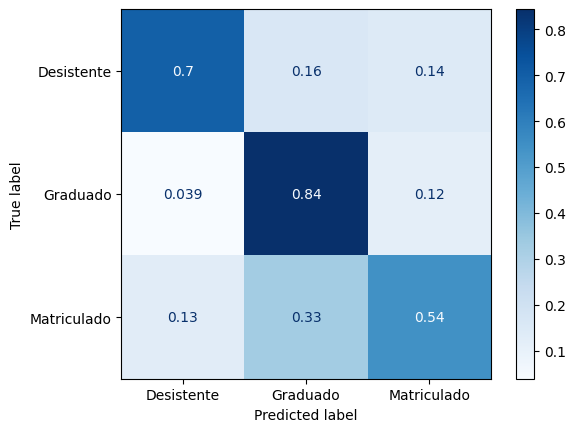

In [91]:
oversample = SMOTE(random_state=0)
X_balanced, y_balanced = oversample.fit_resample(X, y)
model = RandomForestClassifier(max_depth=10, random_state=0)
model.fit(X_balanced, y_balanced)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', cmap='Blues');